In [2]:
import pandas as pd
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Change working directory
import os
os.chdir(os.getcwd() + "/../")

import hyp_config

In [2]:
# Plot settings
xmap = {"n_clusters": "Number of clusters", "eps": "Epsilon", "min_samples": "Minimum number of samples"}
score_name_map = {"calinski": "Calinski-Harabasz Score", "silhouette": "Silhouette Dcore", "davies_bouldin": "Davies-Bouldin Dcore", "nnoise": "Noise [%]", "nclusters": "Number of Clusters"}
c_blue = sns.color_palette("tab10")[0]
c_orange = sns.color_palette("tab10")[1]

In [7]:
def plot_score(df, x):
    fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(8.27, 8.27*0.3))

    # Plot lines
    l1 = sns.lineplot(df[(df["scores_on"] == "original") & (df["clustering_on"] == "original")], x=x, y="calinski", ax=axs[0], c=c_blue, label="original")
    l2 = sns.lineplot(df[(df["scores_on"] == "original") & (df["clustering_on"] == "original")], x=x, y="davies_bouldin", ax=axs[1], c=c_blue, label="original")
    l3 = sns.lineplot(df[(df["scores_on"] == "original") & (df["clustering_on"] == "original")], x=x, y="silhouette", ax=axs[2], c=c_blue, label="original")
    
    l4 = sns.lineplot(df[(df["scores_on"] == "embedding") & (df["clustering_on"] == "embedding")], x=x, y="calinski", ax=axs[0], c=c_orange, label="embedding")
    l5 = sns.lineplot(df[(df["scores_on"] == "embedding") & (df["clustering_on"] == "embedding")], x=x, y="davies_bouldin", ax=axs[1], c=c_orange, label="embedding")
    l6 = sns.lineplot(df[(df["scores_on"] == "embedding") & (df["clustering_on"] == "embedding")], x=x, y="silhouette", ax=axs[2], c=c_orange, label="embedding")
   
    # Define labels
    l1.set_xlabel(None)
    l1.set_ylabel(None)
    l1.set_title(r"Calinski-Harabasz Score $\uparrow$", fontsize=11)
    l1.tick_params(labelsize=8)
    l1.legend(title='Clustering on', loc='center right', fontsize=8, title_fontsize=8)

    l2.set_xlabel(None)
    l2.set_ylabel(None)
    l2.set_title(r"Davies-Bouldin Score $\downarrow$", fontsize=11)
    l2.tick_params(labelsize=8)
    l2.legend(title='Clustering on', loc='center right', fontsize=8, title_fontsize=8)

    l3.set_xlabel(None)
    l3.set_ylabel(None)
    l3.set_title(r"Silhouette Score $\uparrow$", fontsize=11)
    l3.tick_params(labelsize=8)
    l3.legend(title='Clustering on', loc='center right', fontsize=8, title_fontsize=8)

    fig.supxlabel(xmap[x], fontsize=11, y=0.04)
    
    plt.tight_layout()

In [8]:
def plot_heatmap(df, x="min_samples", y="eps", color="nclusters", title="Sweep of DBSAN (on original data)", vmax=None, mask=None, annot=True, patch=None):
    df_temp = df.copy()
    df_temp = df_temp.sort_values([y, x])
    
    idx = df_temp[y].unique()
    cols = df_temp[x].unique()
    field = pd.DataFrame(df_temp[color].to_numpy().reshape(len(idx), len(cols)), index=idx, columns=cols)

    if mask is not None:
        field = field[mask]
            
    h = sns.heatmap(data=field, cbar_kws={'label': score_name_map[color]}, annot=annot, fmt='g', cmap="gray", vmax=vmax)
    h.figure.axes[-1].yaxis.label.set_size(11)
    plt.gca().invert_yaxis()
    if patch:
        h.add_patch(Rectangle((np.where(cols == patch[1])[0][0], np.where(idx == patch[0])[0][0]), 1, 1, fill=False, edgecolor="red", lw=2))
    plt.xlabel(x, fontsize=11)
    plt.ylabel(y, fontsize=11)
    plt.title(title, fontsize=11)
    plt.tick_params(axis='both', which='minor', labelsize=8)
    plt.tight_layout()

    return field, find_max_diff(field)

In [9]:
def find_max_diff(field):
    diff_max = 0
    col_max0 = 0
    row_max0 = 0
    col_max1 = 0
    row_max1 = 0
    
    def update(diff_new, col_max0_new, row_max0_new, col_max1_new, row_max1_new, diff_max, col_max0, row_max0, col_max1, row_max1):
        if diff_new > diff_max:
            return diff_new, col_max0_new, row_max0_new, col_max1_new, row_max1_new
        else:
            return diff_max, col_max0, row_max0, col_max1, row_max1
    
    for col_idx, col in enumerate(field.columns):
        for row_idx, row in enumerate(field.index):
            n = field.iloc[row_idx, col_idx]
    
            # init parameters
            diff_l = 0
            diff_r = 0
            diff_u = 0
            diff_d = 0
    
            # compute differences to all neighbouring table entries
            # column left
            if col_idx != 0:
                diff_l = abs(n - field.iloc[row_idx, col_idx-1])
                diff_max, col_max0, row_max0, col_max1, row_max1 = update(diff_l, col_idx, row_idx, col_idx-1, row_idx, diff_max, col_max0, row_max0, col_max1, row_max1)
    
            # column right
            if col_idx != len(field.columns) - 1:
                diff_r = abs(n - field.iloc[row_idx, col_idx+1])
                diff_max, col_max0, row_max0, col_max1, row_max1 = update(diff_r, col_idx, row_idx, col_idx+1, row_idx, diff_max, col_max0, row_max0, col_max1, row_max1)
    
            # row up
            if row_idx != 0:
                diff_u = abs(n - field.iloc[row_idx-1, col_idx])
                diff_max, col_max0, row_max0, col_max1, row_max1 = update(diff_u, col_idx, row_idx, col_idx, row_idx-1, diff_max, col_max0, row_max0, col_max1, row_max1)
    
            # row down
            if row_idx != len(field.index) - 1:
                diff_d = abs(n - field.iloc[row_idx+1, col_idx])
                diff_max, col_max0, row_max0, col_max1, row_max1 = update(diff_d, col_idx, row_idx, col_idx, row_idx+1, diff_max, col_max0, row_max0, col_max1, row_max1)

    return diff_max, col_max0, row_max0, col_max1, row_max1

# Load data

In [13]:
df_kmeans = pd.read_csv(f"{config.output_dir_clustering}scores_kmeans.csv")
df_ward = pd.read_csv(f"{config.output_dir_clustering}scores_ward.csv")
df_dbscan = pd.read_csv(f"{config.output_dir_clustering}scores_dbscan.csv")

# Compare across algorithms
Using the finally selected hyperparameter combinations, compare the CVIs for the algorithms. 

In [16]:
# Kmeans original
query_str = " & ".join([f"{k} == @v" for k, v in hyp_config.kmeans_original_hyps.items()])
query_str += ' & clustering_on == "original"'
ko = df_kmeans.query(query_str)

# Kmeans embedding
query_str = " & ".join([f"{k} == @v" for k, v in hyp_config.kmeans_umap_hyps.items()])
query_str += ' & clustering_on == "embedding"'
ke = df_kmeans.query(query_str)

# Ward original
query_str = " & ".join([f"{k} == @v" for k, v in hyp_config.ward_original_hyps.items()])
query_str += ' & clustering_on == "original"'
wo = df_ward.query(query_str)

# Ward embedding
query_str = " & ".join([f"{k} == @v" for k, v in hyp_config.ward_umap_hyps.items()])
query_str += ' & clustering_on == "embedding"'
we = df_ward.query(query_str)

# DBSCAN original
query_str = " & ".join([f"{k} == @v" for k, v in hyp_config.dbscan_original_hyps.items()])
query_str += ' & clustering_on == "original"'
do = df_dbscan.query(query_str)

# DBSCAN embedding
query_str = " & ".join([f"{k} == @v" for k, v in hyp_config.dbscan_umap_hyps.items()])
query_str += ' & clustering_on == "embedding"'
de = df_dbscan.query(query_str)

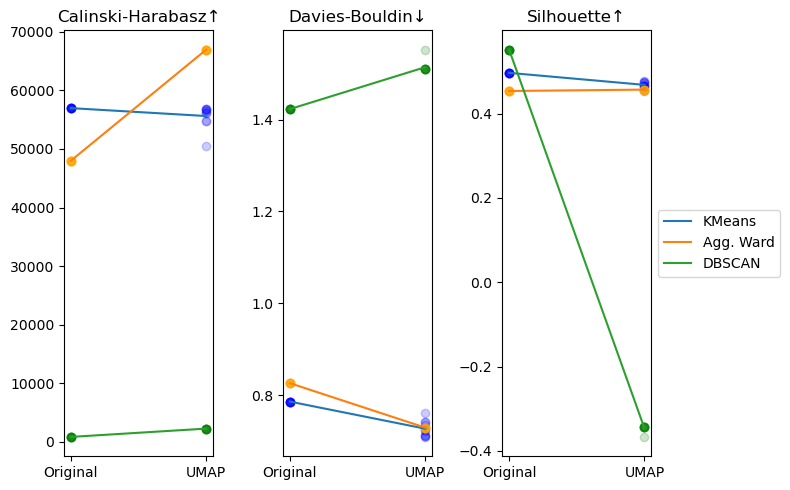

In [30]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(8, 5))
alpha = 0.2
for i, score, score_name in [(0, "calinski", "Calinski-Harabasz"), (1, "davies_bouldin", "Davies-Bouldin"), (2, "silhouette", "Silhouette")]:
    title = score_name + "\u2191"
    if score_name == "Davies-Bouldin": 
        title = score_name + "\u2193"
    axs[i].set_title(title)
    axs[i].set_xticks([0, 1], ["Original", "UMAP"])

    axs[i].scatter([0]*len(ko), ko[score], color="blue", alpha=alpha)
    axs[i].scatter([1]*len(ke), ke[score], color="blue", alpha=alpha)
    axs[i].plot([0, 1], [ko[score].mean(), ke[score].mean()], color="tab:blue", label="KMeans")

    axs[i].scatter([0]*len(wo), wo[score], color="orange", alpha=alpha)
    axs[i].scatter([1]*len(we), we[score], color="orange", alpha=alpha)
    axs[i].plot([0, 1], [wo[score].mean(), we[score].mean()], color="tab:orange", label="Agg. Ward")

    axs[i].scatter([0]*len(do), do[score], color="green", alpha=alpha)
    axs[i].scatter([1]*len(de), de[score], color="green", alpha=alpha)
    axs[i].plot([0, 1], [do[score].mean(), de[score].mean()], color="tab:green", label="DBSCAN")
    
axs[i].legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
#plt.savefig(f"{config.output_dir_plots}score_comparison.png")
plt.savefig(f"{config.output_dir_plots_high_res}score_comparison.png", dpi=1000)
plt.show()

In [18]:
# Correlations between the scores
all = pd.concat([ko, ke, wo, we, do, de])
print(f"Correlation Si-DB: {np.corrcoef(all['silhouette'], all['davies_bouldin'])[0, 1]}")
print(f"Correlation Si-CH: {np.corrcoef(all['silhouette'], all['calinski'])[0,1]}")
print(f"Correlation DB-CH: {np.corrcoef(all['calinski'], all['davies_bouldin'])[0,1]}")

Correlation Si-DB: -0.6147070550425913
Correlation Si-CH: 0.5293283962129272
Correlation DB-CH: -0.9846561555900789


# KMeans

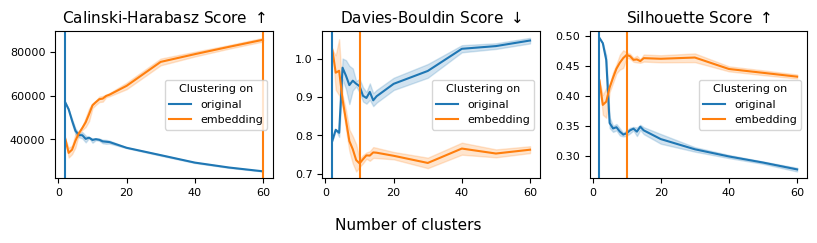

In [28]:
plot_score(df_kmeans, x="n_clusters")
# plt.savefig(f"{config.output_dir_plots}score_kmeans.png")
plt.savefig(f"{config.output_dir_plots_high_res}score_kmeans.png", dpi=1000)
plt.show()

# Agglomerative Ward

In [24]:
df_ward = df_ward.drop("distance_threshold", axis=1)

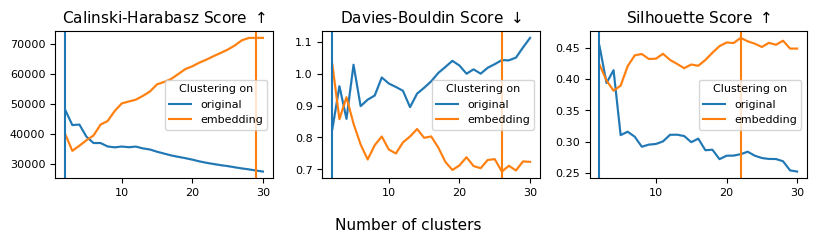

In [31]:
plot_score(df_ward, x="n_clusters")
# plt.savefig(f"{config.output_dir_plots}score_ward.png")
plt.savefig(f"{config.output_dir_plots_high_res}score_ward.png", dpi=1000)
plt.show()

# DBSCAN

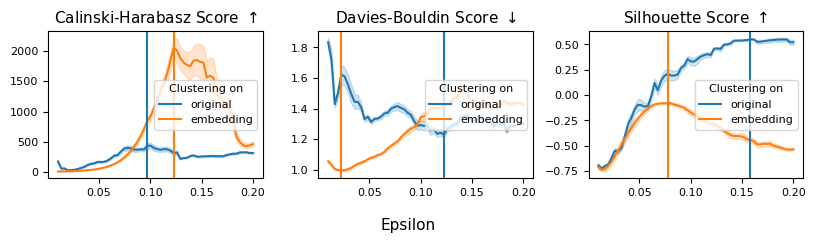

In [93]:
plot_score(df_dbscan, x="eps")
plt.savefig(f"{config.output_dir_plots}score_dbscan_eps.png")
plt.show()

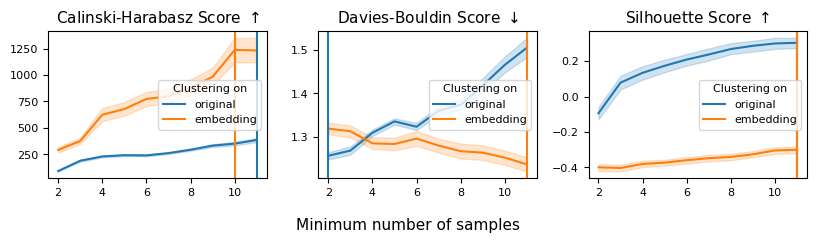

In [94]:
plot_score(df_dbscan, x="min_samples")
plt.savefig(f"{config.output_dir_plots}score_dbscan_min_samples.png")
plt.show()

## Heatmaps
The tuning of 2 parameters instead of one is more complex due to the interaction between the parameters. Therefore, considering plots displaying only one parameter is less descriptive of the actual behaviour. Therefore, we plot the following heatmap.

In [33]:
# Average scores over iterations
df_dbscan_i = df_dbscan.groupby(["eps", "min_samples", "clustering_on"]).mean().drop("iteration", axis=1).reset_index()

In [39]:
def find_steepest_gradient(df, value_col="calinski"):
    temp = df.copy()
    
    # Normalize columns for consistent scaling
    temp['eps_norm'] = (temp['eps'] - temp['eps'].min()) / (temp['eps'].max() - temp['eps'].min())
    temp['min_samples_norm'] = (temp['min_samples'] - temp['min_samples'].min()) / (temp['min_samples'].max() - temp['min_samples'].min())
    temp['calinski_norm'] = (temp[value_col] - temp[value_col].min()) / (temp[value_col].max() - temp[value_col].min())
    
    # Pivot to create a 2D grid
    grid = temp.pivot(index='min_samples_norm', columns='eps_norm', values='calinski_norm')
    grid = grid.interpolate(method='linear', axis=0).interpolate(method='linear', axis=1)  # Fill missing values

    # Calculate gradients
    grad_eps, grad_min_samples = np.gradient(grid.values)  # Numerical differentiation

    # Compute gradient magnitude
    grad_magnitude = np.sqrt(grad_eps**2 + grad_min_samples**2)

    # Find the index of the maximum gradient
    max_idx = np.unravel_index(np.argmax(grad_magnitude), grad_magnitude.shape)
    max_min_samples_norm = grid.index[max_idx[0]]
    max_eps_norm = grid.columns[max_idx[1]]

    # Map back to original scale
    max_eps = max_eps_norm * (temp['eps'].max() - temp['eps'].min()) + temp['eps'].min()
    max_min_samples = max_min_samples_norm * (temp['min_samples'].max() - temp['min_samples'].min()) + temp['min_samples'].min()

    return max_eps, max_min_samples

# Steepest gradient for calinski score
temp = df_dbscan_i[(df_dbscan_i.scores_on == "embedding") & (df_dbscan_i.clustering_on == "embedding")]
e, m = find_steepest_gradient(temp)

In [15]:
hyp_dict = {"eps": np.linspace(0.01, 0.2, 60), "min_samples": range(2, 12)}

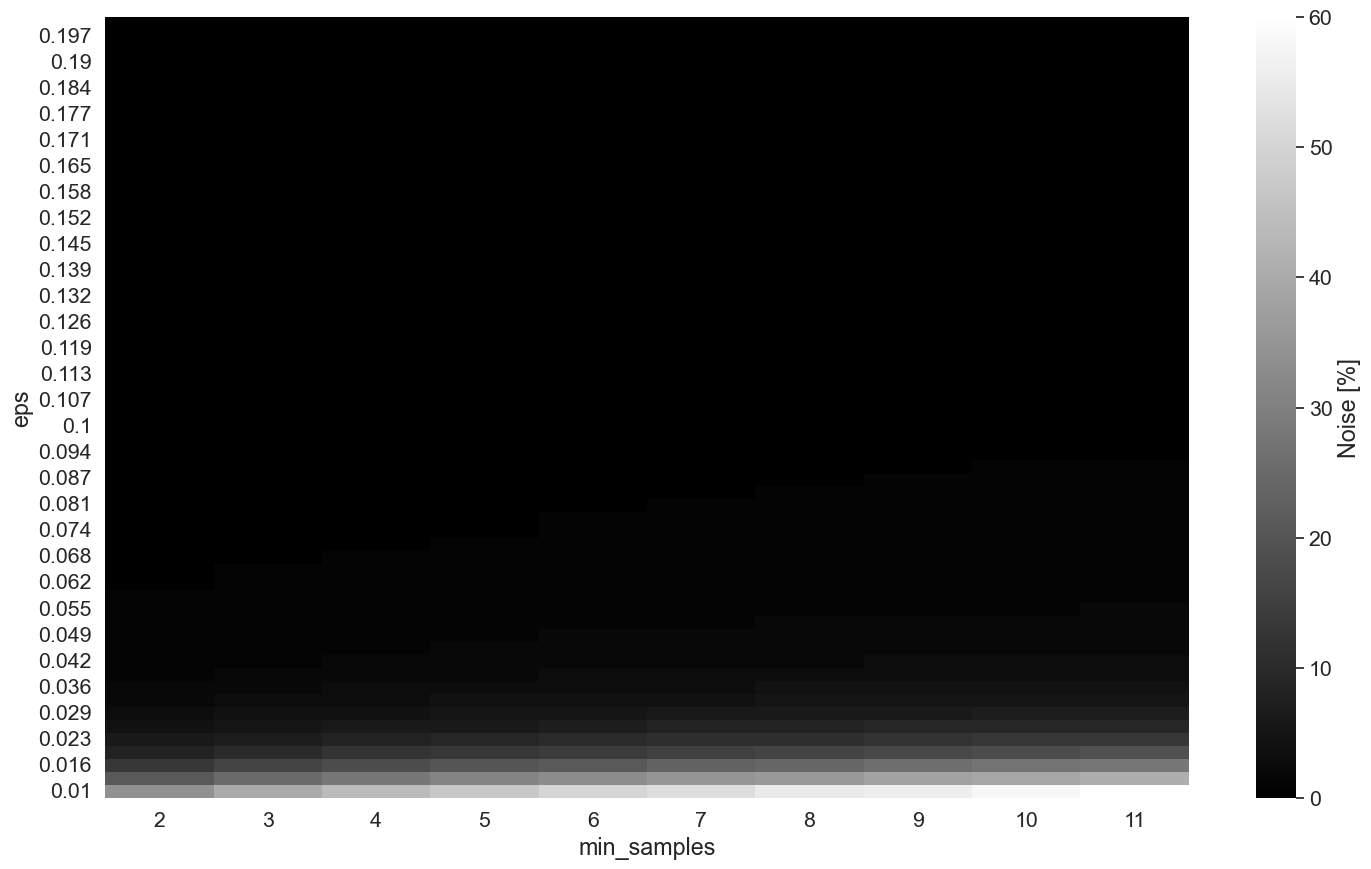

Maximum gradient: 19.0, between entry(col, row) (6, 0) and entry(col, row) (6, 1)


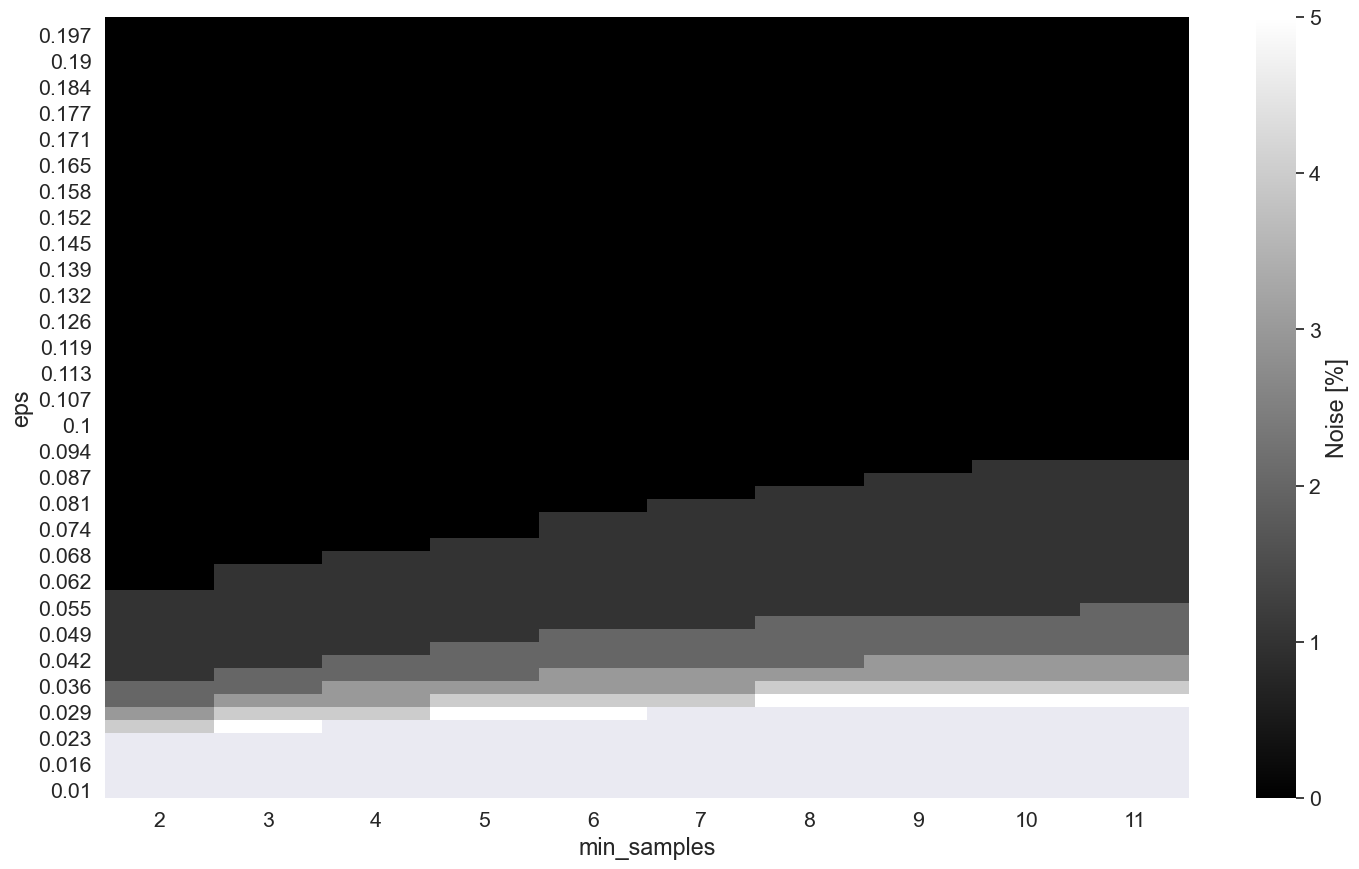

Maximum gradient (nnoise <=5): 1.0, between entry(col, row) (0, 5) and entry(col, row) (1, 5)


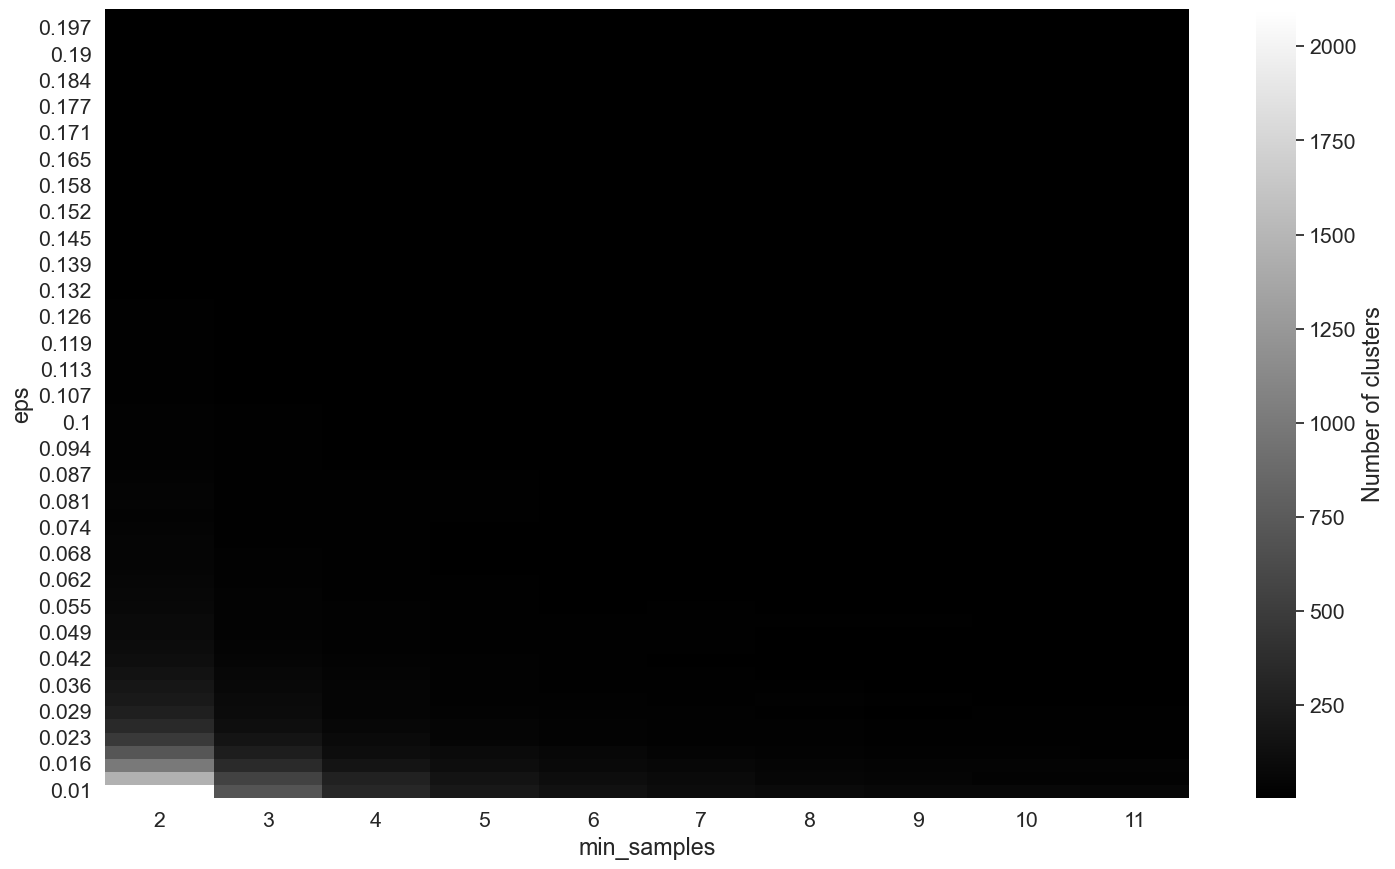

Maximum gradient: 1404.0, between entry(col, row) (0, 0) and entry(col, row) (1, 0)


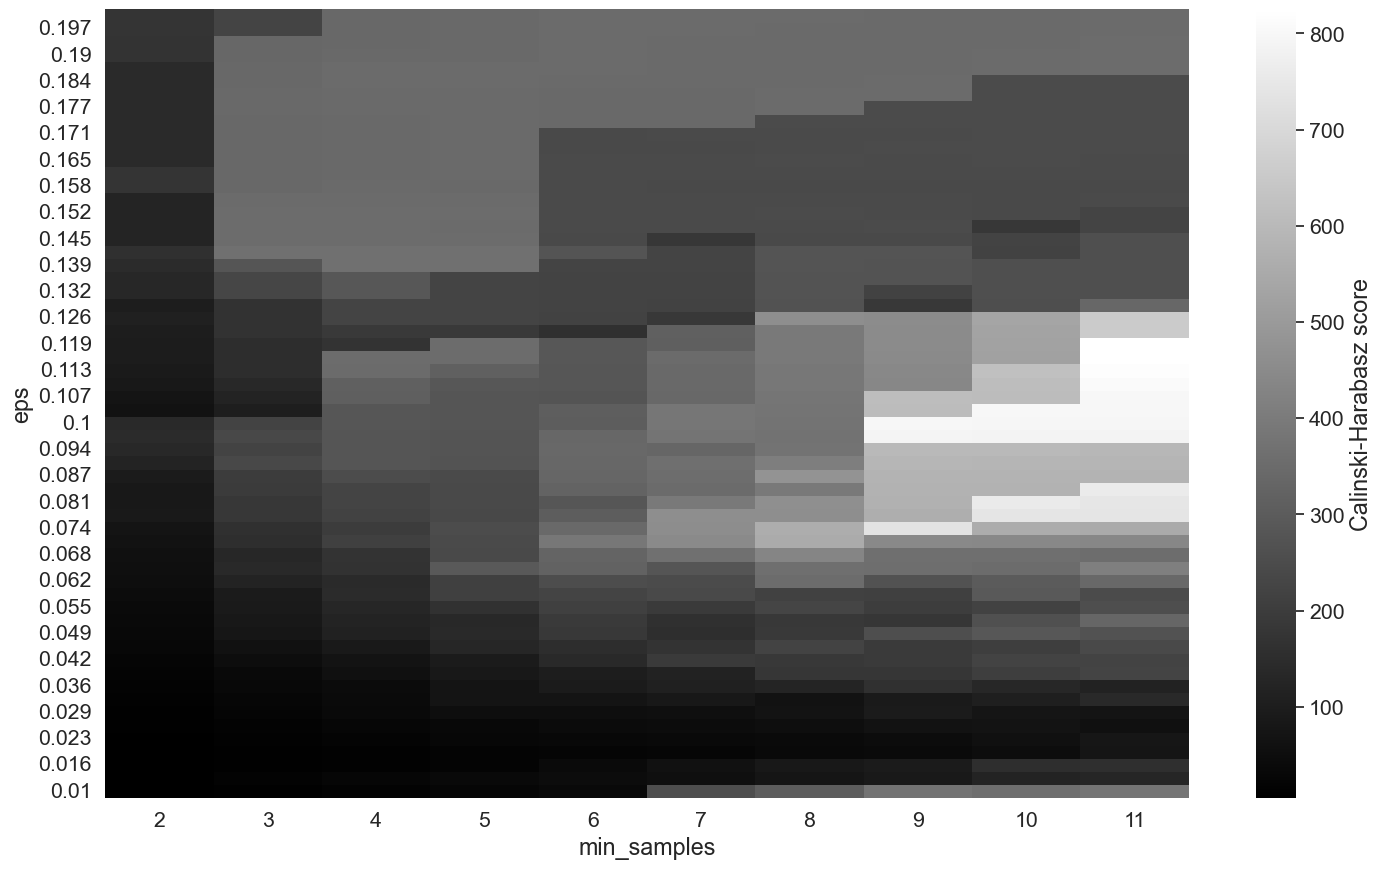

Maximum Calinski-Harabasz score here:         eps  min_samples clustering_on scores_on  nclusters  silhouette  \
1399  0.119           11      original  original        4.0       0.552   

      davies_bouldin  calinski  nnoise  
1399            1.42     825.0     0.0  
Maximum Calinski-Harabasz score (where nnoise<=5) here:         eps  min_samples clustering_on scores_on  nclusters  silhouette  \
1399  0.119           11      original  original        4.0       0.552   

      davies_bouldin  calinski  nnoise  
1399            1.42     825.0     0.0  


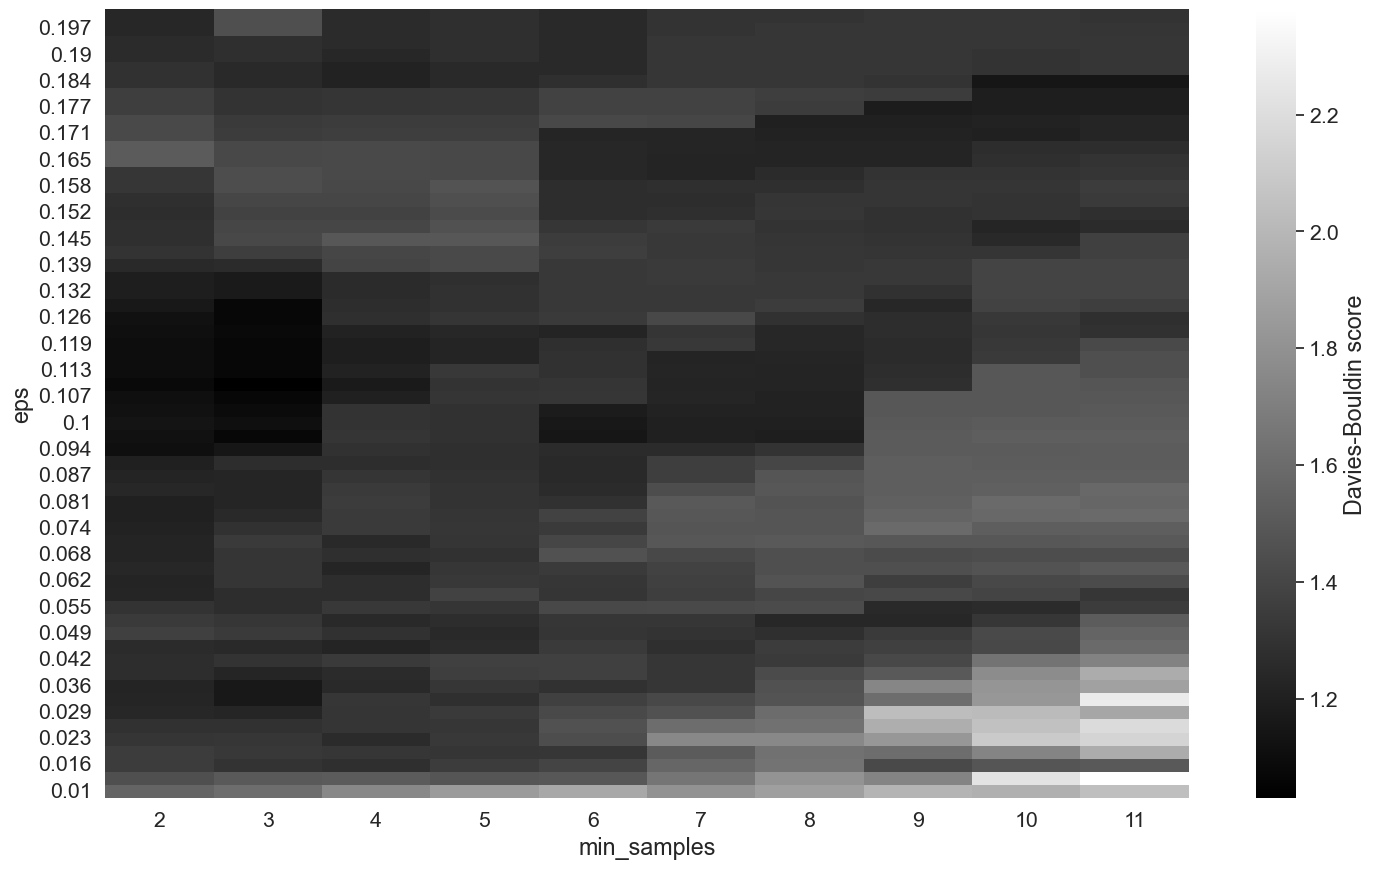

Minimum Davies-Bouldin score here:        eps  min_samples clustering_on scores_on  nclusters  silhouette  \
1247  0.11            3      original  original       10.0       0.404   

      davies_bouldin  calinski  nnoise  
1247            1.03     136.0     0.0  
Minimum Davies-Bouldin score (where nnoise<=5) here:        eps  min_samples clustering_on scores_on  nclusters  silhouette  \
1247  0.11            3      original  original       10.0       0.404   

      davies_bouldin  calinski  nnoise  
1247            1.03     136.0     0.0  


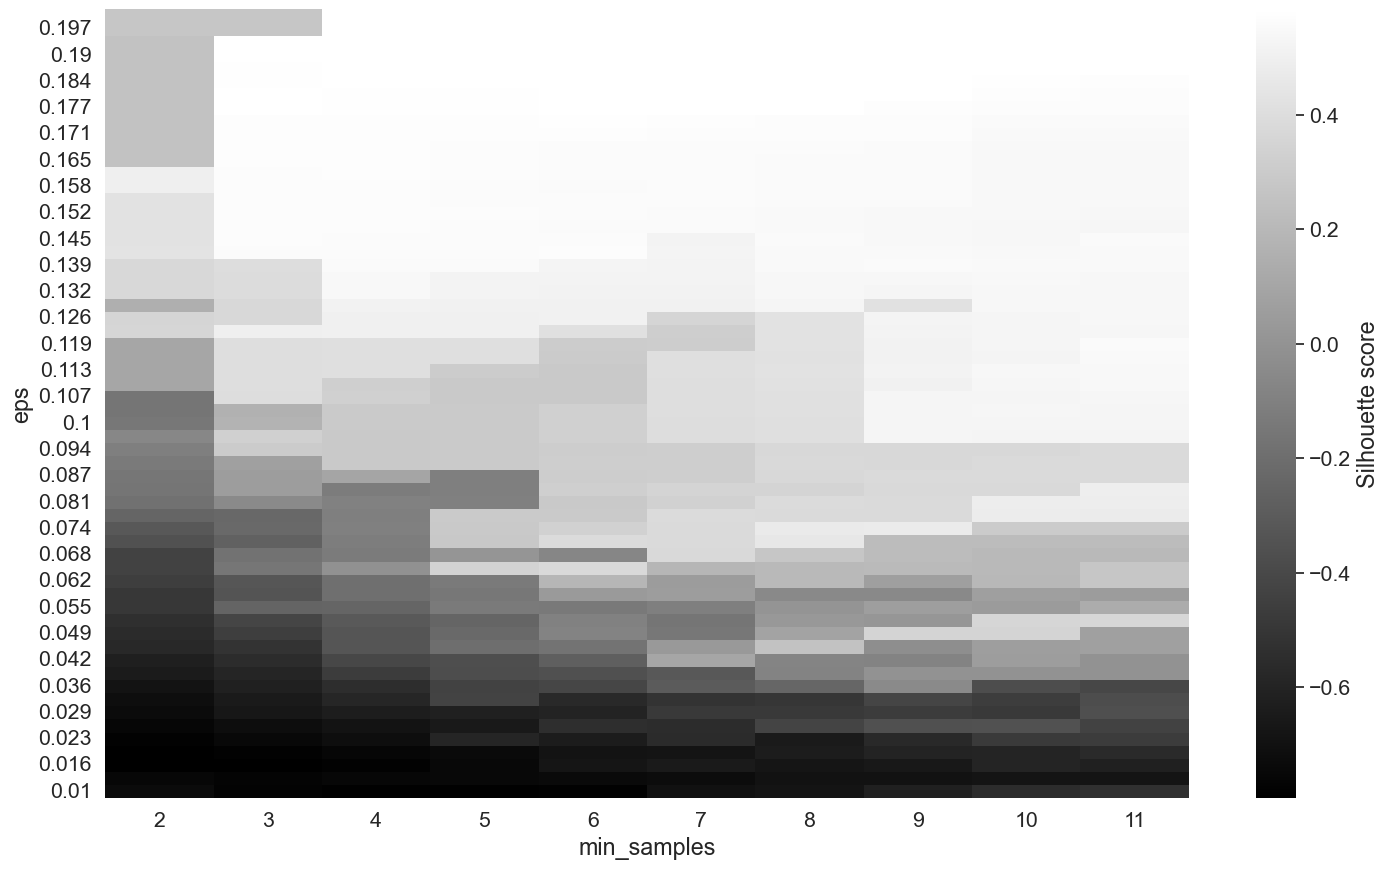

Maximum Silhouette score here:         eps  min_samples clustering_on scores_on  nclusters  silhouette  \
2171  0.184            4      original  original        3.0       0.584   
2183  0.184            7      original  original        3.0       0.584   
2187  0.184            8      original  original        3.0       0.584   
2191  0.184            9      original  original        3.0       0.584   
2211  0.187            4      original  original        3.0       0.584   
2223  0.187            7      original  original        3.0       0.584   
2227  0.187            8      original  original        3.0       0.584   
2231  0.187            9      original  original        3.0       0.584   
2235  0.187           10      original  original        3.0       0.584   
2263  0.190            7      original  original        3.0       0.584   
2267  0.190            8      original  original        3.0       0.584   
2271  0.190            9      original  original        3.0       0.5

In [34]:
# Plot score heatmap for clustering on original and scores on original
clustering_on = "original"
scores_on = "original"

plt.rcParams["figure.figsize"] = (15, 9)
sns.set(font_scale=1.4)

# prepare and filter data
temp = df_dbscan_i[(df_dbscan_i["clustering_on"] == clustering_on) & (df_dbscan_i["scores_on"] == scores_on)].copy()
temp.eps = temp.eps.round(3)
temp.min_samples = temp.min_samples.astype(int)
temp.silhouette = temp.silhouette.round(3)
temp.calinski = temp.calinski.round()
temp.davies_bouldin = temp.davies_bouldin.round(2)
temp.nclusters = np.round(temp.nclusters)
temp["nnoise"] = round(temp["nnoise"]*100/49131)
t = temp[temp.nnoise <= 5]

# noise fraction
# field_n, [diff_max_n, col_max0_n, row_max0_n, col_max1_n, row_max1_n] = plot_heatmap(temp, x="min_samples", y="eps", color="nnoise", title=f"Sweep of DBSCAN (clustering on {clustering_on}, scores on {scores_on})")
field_n, [diff_max_n, col_max0_n, row_max0_n, col_max1_n, row_max1_n] = plot_heatmap(temp, x="min_samples", y="eps", color="nnoise", title="", annot=False)
plt.show()
print(f"Maximum gradient: {diff_max_n}, between entry(col, row) {col_max0_n, row_max0_n} and entry(col, row) {col_max1_n, row_max1_n}")

# noise fraction (with mask for 5%)
# field_5, [diff_max_5, col_max0_5, row_max0_5, col_max1_5, row_max1_5] = plot_heatmap(temp, x="min_samples", y="eps", color="nnoise", title=f"Sweep of DBSCAN (clustering on {clustering_on}, scores on {scores_on})", mask=field_n <= 5)
field_5, [diff_max_5, col_max0_5, row_max0_5, col_max1_5, row_max1_5] = plot_heatmap(temp, x="min_samples", y="eps", color="nnoise", title="", mask=field_n <= 5, annot=False)
plt.show()
print(f"Maximum gradient (nnoise <=5): {diff_max_5}, between entry(col, row) {col_max0_5, row_max0_5} and entry(col, row) {col_max1_5, row_max1_5}")

# number of clusters
# field, [diff_max, col_max0, row_max0, col_max1, row_max1] = plot_heatmap(temp, x="min_samples", y="eps", color="nclusters", title=f"Sweep of DBSCAN (clustering on {clustering_on}, scores on {scores_on})")
field, [diff_max, col_max0, row_max0, col_max1, row_max1] = plot_heatmap(temp, x="min_samples", y="eps", color="nclusters", title="", annot=False)
plt.savefig(f"{config.output_dir_plots}dbscan/sweep_clustering_on_{clustering_on}_scores_on{scores_on}.png")
plt.show()
print(f"Maximum gradient: {diff_max}, between entry(col, row) {col_max0, row_max0} and entry(col, row) {col_max1, row_max1}")

# Calinski-Harabasz
# field_ch, vs_ch = plot_heatmap(temp, x="min_samples", y="eps", color="calinski", title=f"Sweep of DBSCAN (clustering on {clustering_on}, scores on {scores_on})")
field_ch, vs_ch = plot_heatmap(temp, x="min_samples", y="eps", color="calinski", title="", annot=False)
plt.show()
print(f"Maximum Calinski-Harabasz score here: {temp[temp.calinski == temp.calinski.max()]}")
print(f"Maximum Calinski-Harabasz score (where nnoise<=5) here: {t[t.calinski == t.calinski.max()]}")

# Davies-Bouldin
# field_db, vs_db = plot_heatmap(temp, x="min_samples", y="eps", color="davies_bouldin", title=f"Sweep of DBSCAN (clustering on {clustering_on}, scores on {scores_on})")
field_db, vs_db = plot_heatmap(temp, x="min_samples", y="eps", color="davies_bouldin", title="", annot=False)
plt.show()
print(f"Minimum Davies-Bouldin score here: {temp[temp.davies_bouldin == temp.davies_bouldin.min()]}")
print(f"Minimum Davies-Bouldin score (where nnoise<=5) here: {t[t.davies_bouldin == t.davies_bouldin.min()]}")

# Silhouette
# field_s, vs_s = plot_heatmap(temp, x="min_samples", y="eps", color="silhouette", title=f"Sweep of DBSCAN (clustering on {clustering_on}, scores on {scores_on})")
field_s, vs_s = plot_heatmap(temp, x="min_samples", y="eps", color="silhouette", title="", annot=False)
plt.show()
print(f"Maximum Silhouette score here: {temp[temp.silhouette == temp.silhouette.max()]}")
print(f"Maximum Silhouette score (where nnoise<=5) here: {t[t.silhouette == t.silhouette.max()]}")

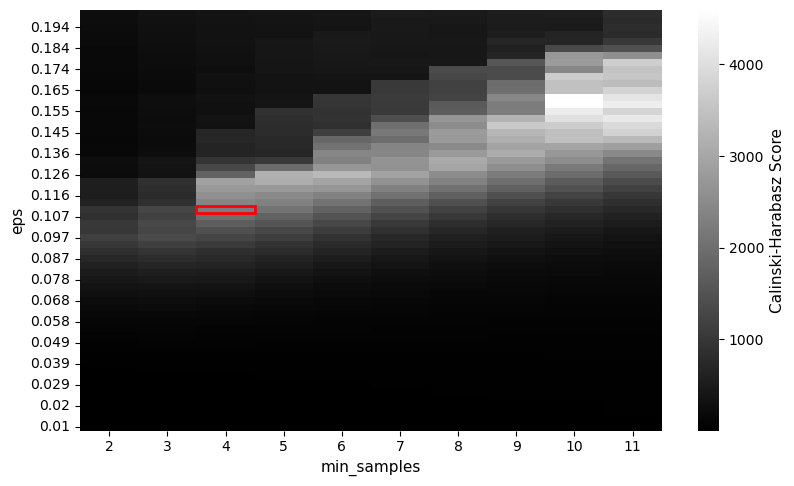

Maximum Calinski-Harabasz score here:         eps  min_samples clustering_on  scores_on  nclusters  silhouette  \
1872  0.158           10     embedding  embedding      117.0      -0.222   

      davies_bouldin  calinski  nnoise  
1872            1.59    4597.0     4.0  
Maximum Calinski-Harabasz score (where nnoise<=5) here:         eps  min_samples clustering_on  scores_on  nclusters  silhouette  \
1872  0.158           10     embedding  embedding      117.0      -0.222   

      davies_bouldin  calinski  nnoise  
1872            1.59    4597.0     4.0  


In [22]:
# plot score heatmap for clustering on embedding and scores on embedding
clustering_on = "embedding"
scores_on = "embedding"

plt.rcParams["figure.figsize"] = (8.27, 8.27*0.6)  # (15, 6)
# sns.set(font_scale=1.4)

# prepare and filter data
temp = df_dbscan_i[(df_dbscan_i["clustering_on"] == clustering_on) & (df_dbscan_i["scores_on"] == scores_on)].copy()
temp.eps = temp.eps.round(3)
temp.min_samples = temp.min_samples.astype(int)
temp.silhouette = temp.silhouette.round(3)
temp.calinski = temp.calinski.round()
temp.davies_bouldin = temp.davies_bouldin.round(2)
temp.nclusters = np.round(temp.nclusters)
temp["nnoise"] = round(temp["nnoise"]*100/49131)
t = temp[temp.nnoise <= 5]

# Calinski-Harabasz
# field_ch, vs_ch = plot_heatmap(temp, x="min_samples", y="eps", color="calinski", title=f"Sweep of DBSCAN (clustering on {clustering_on}, scores on {scores_on})")
field_ch, vs_ch = plot_heatmap(temp, x="min_samples", y="eps", color="calinski", title="", annot=False, patch=(np.round(0.10983051, 3), 4))
# plt.savefig(f"{config.output_dir_plots}dbscan/sweep_clustering_on_{clustering_on}_scores_on{scores_on}_calinski.png")
plt.show()
print(f"Maximum Calinski-Harabasz score here: {temp[temp.calinski == temp.calinski.max()]}")
print(f"Maximum Calinski-Harabasz score (where nnoise<=5) here: {t[t.calinski == t.calinski.max()]}")


In [40]:
np.sort(temp.eps.unique())

array([0.01      , 0.01322034, 0.01644068, 0.01966102, 0.02288136,
       0.02610169, 0.02932203, 0.03254237, 0.03576271, 0.03898305,
       0.04220339, 0.04542373, 0.04864407, 0.05186441, 0.05508475,
       0.05830508, 0.06152542, 0.06474576, 0.0679661 , 0.07118644,
       0.07440678, 0.07762712, 0.08084746, 0.0840678 , 0.08728814,
       0.09050847, 0.09372881, 0.09694915, 0.10016949, 0.10338983,
       0.10661017, 0.10983051, 0.11305085, 0.11627119, 0.11949153,
       0.12271186, 0.1259322 , 0.12915254, 0.13237288, 0.13559322,
       0.13881356, 0.1420339 , 0.14525424, 0.14847458, 0.15169492,
       0.15491525, 0.15813559, 0.16135593, 0.16457627, 0.16779661,
       0.17101695, 0.17423729, 0.17745763, 0.18067797, 0.18389831,
       0.18711864, 0.19033898, 0.19355932, 0.19677966, 0.2       ])

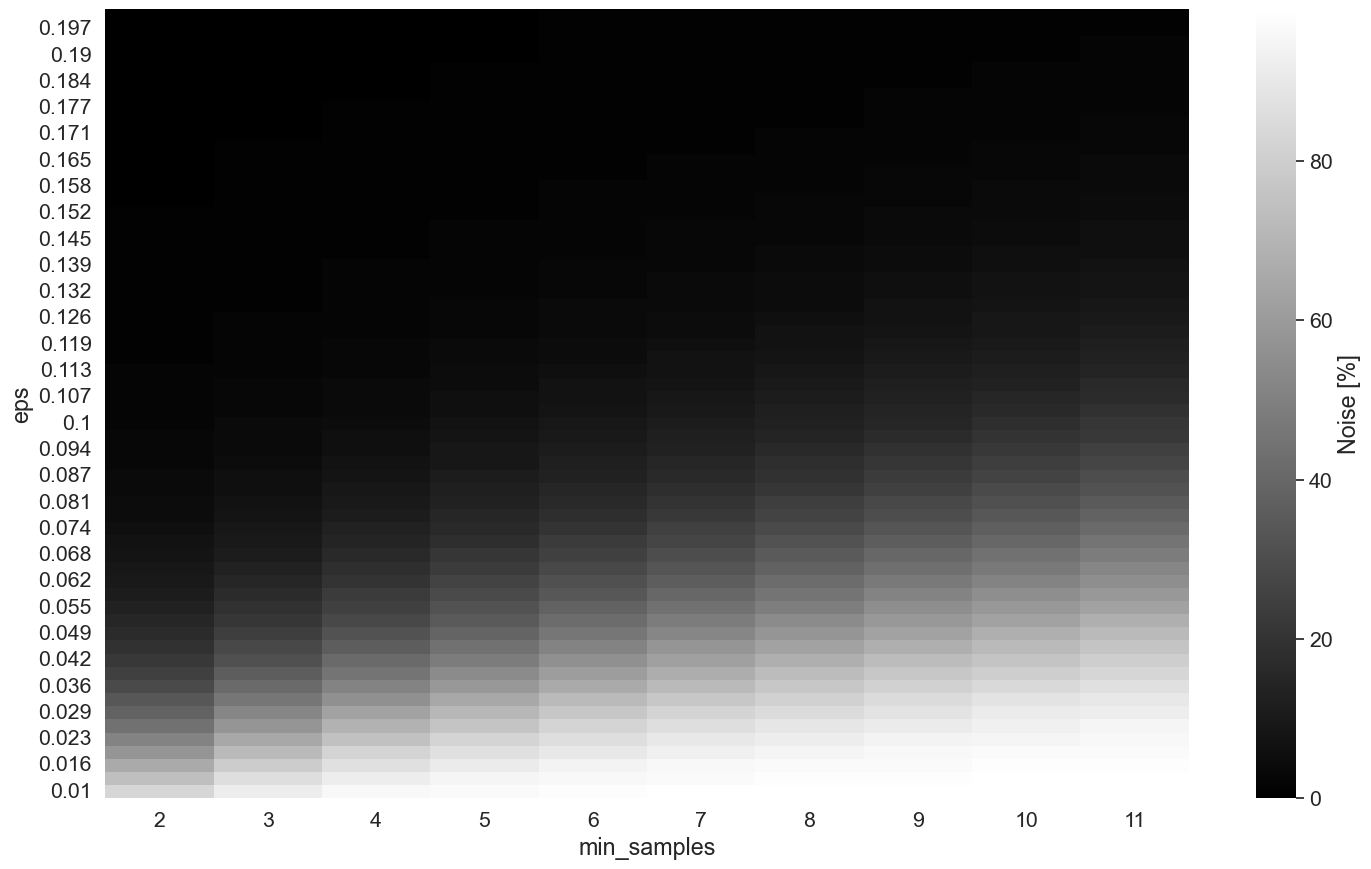

Maximum gradient: 14.0, between entry(col, row) (0, 3) and entry(col, row) (1, 3)


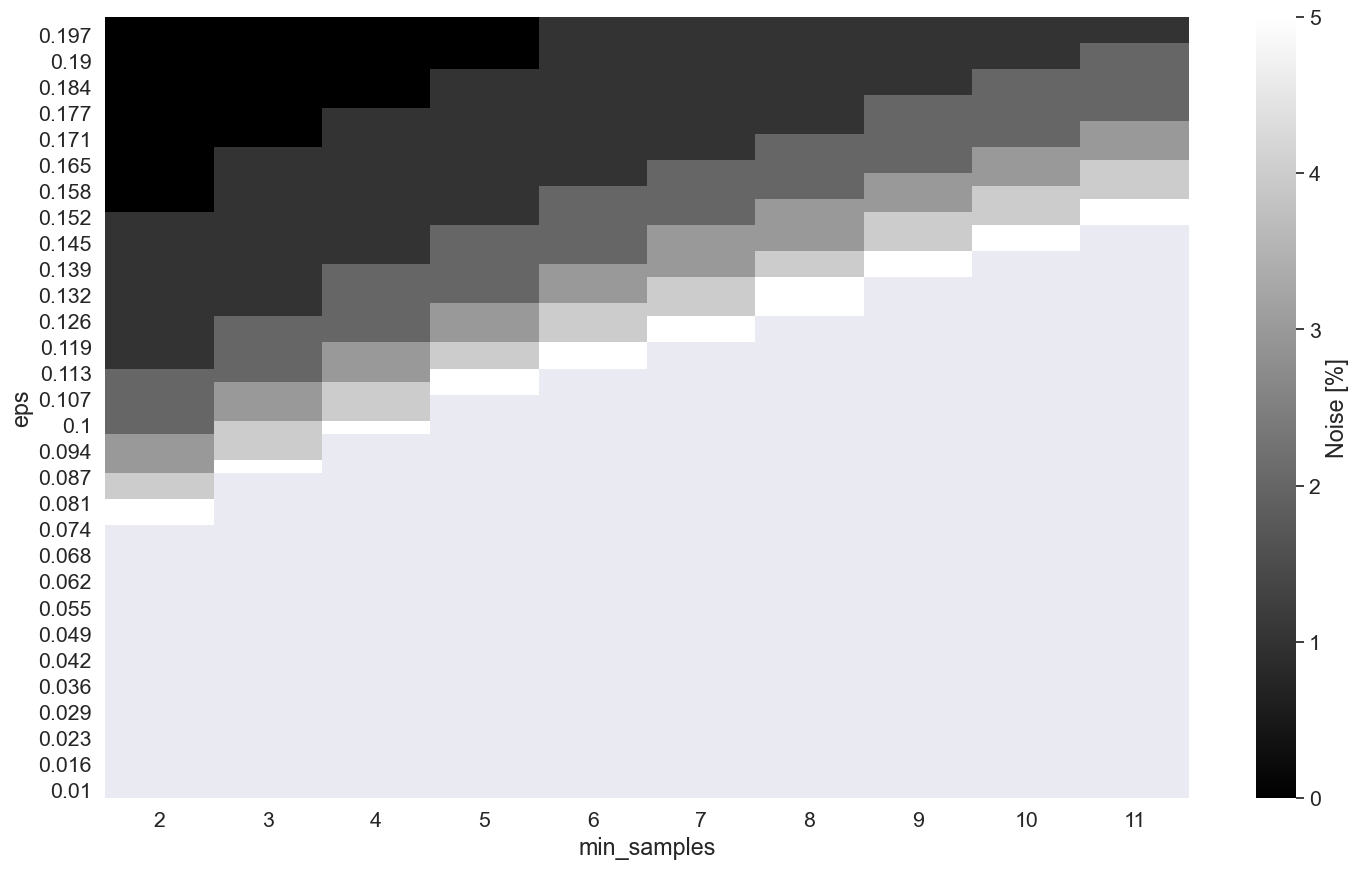

Maximum gradient (nnoise <=5): 2.0, between entry(col, row) (0, 25) and entry(col, row) (1, 25)


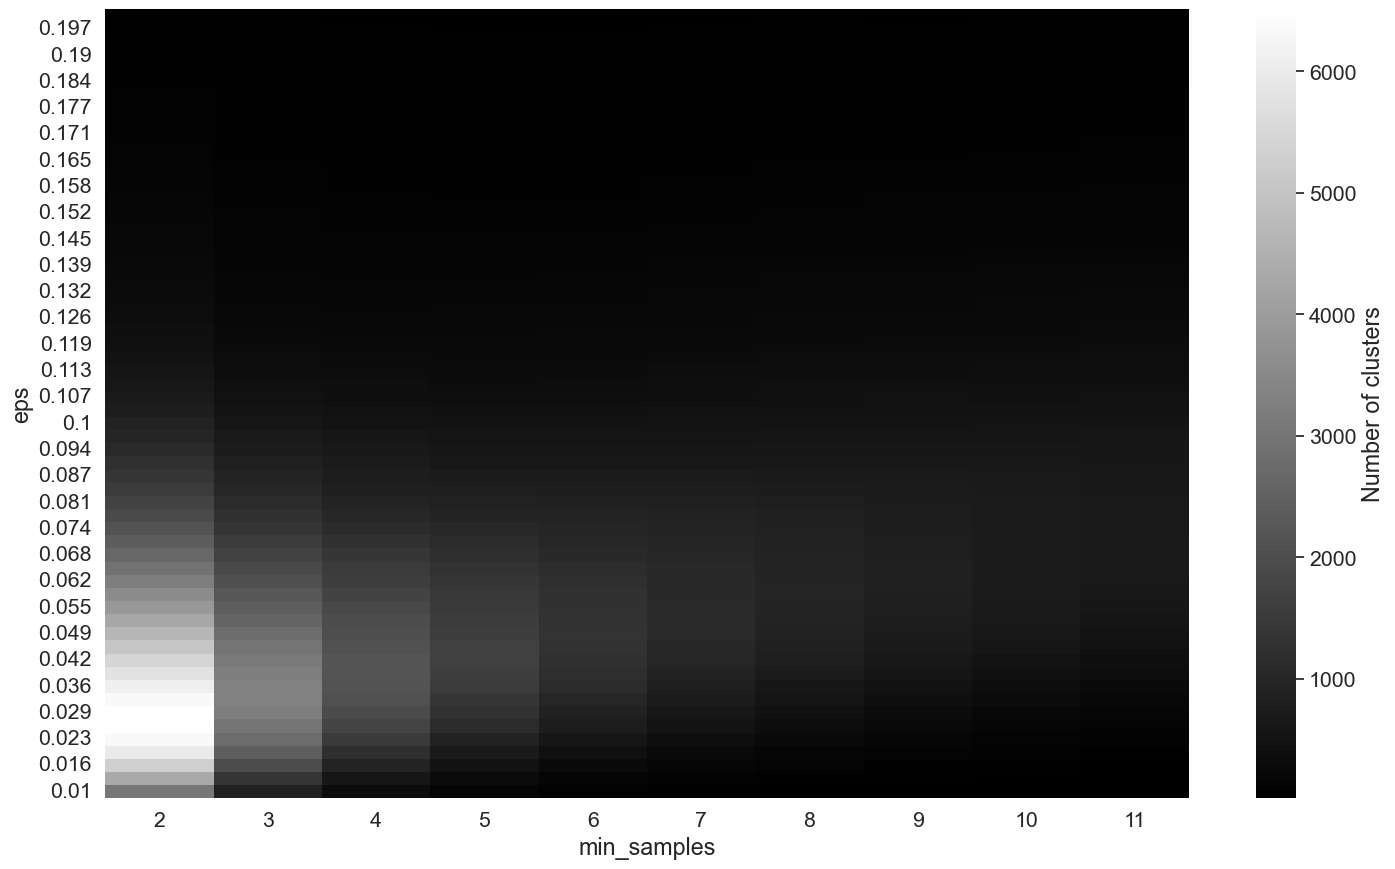

Maximum gradient: 3569.0, between entry(col, row) (0, 4) and entry(col, row) (1, 4)


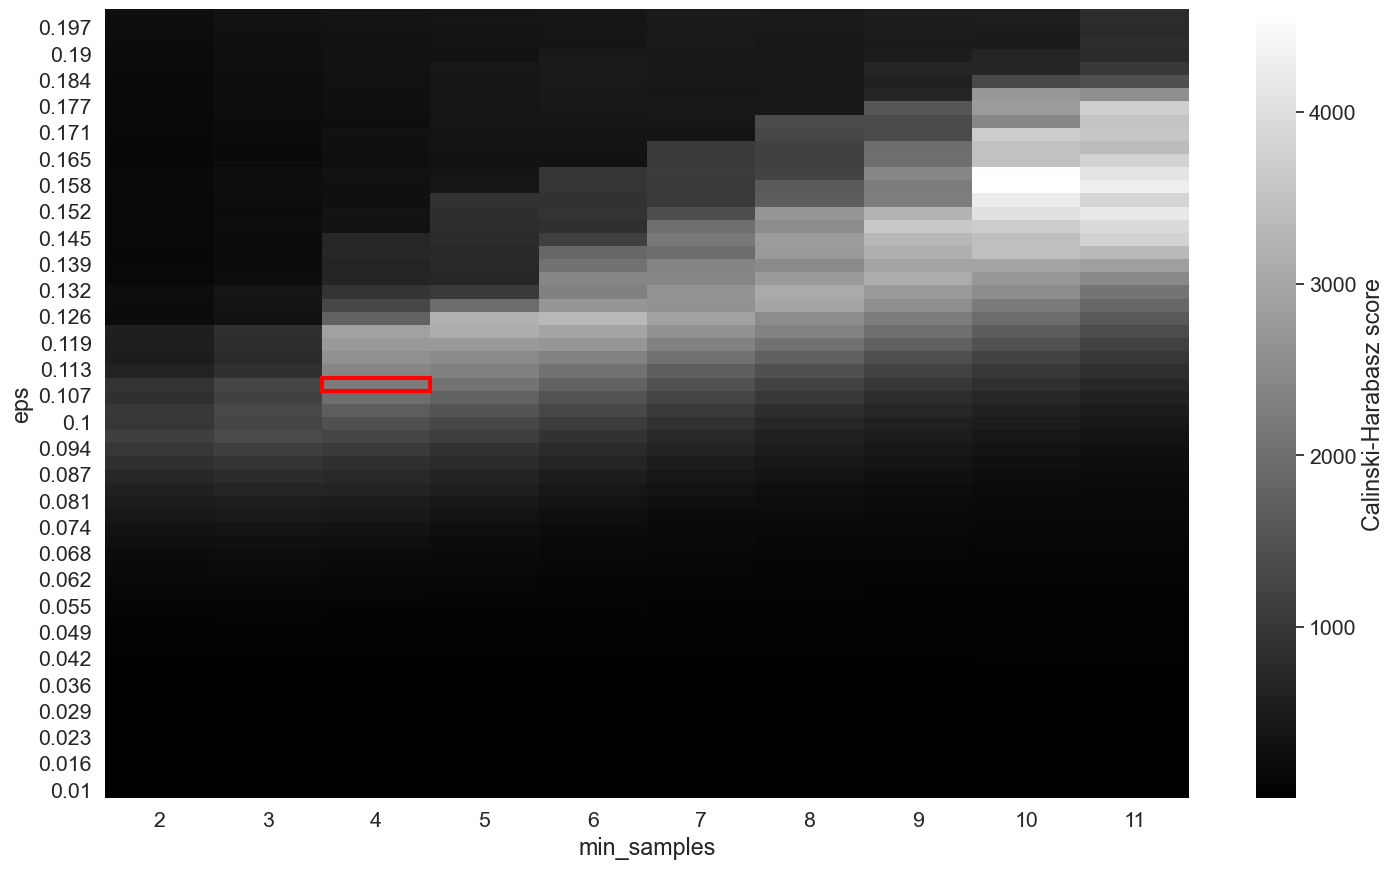

Maximum Calinski-Harabasz score here:         eps  min_samples clustering_on  scores_on  nclusters  silhouette  \
1872  0.158           10     embedding  embedding      117.0      -0.222   

      davies_bouldin  calinski  nnoise  
1872            1.59    4597.0     4.0  
Maximum Calinski-Harabasz score (where nnoise<=5) here:         eps  min_samples clustering_on  scores_on  nclusters  silhouette  \
1872  0.158           10     embedding  embedding      117.0      -0.222   

      davies_bouldin  calinski  nnoise  
1872            1.59    4597.0     4.0  


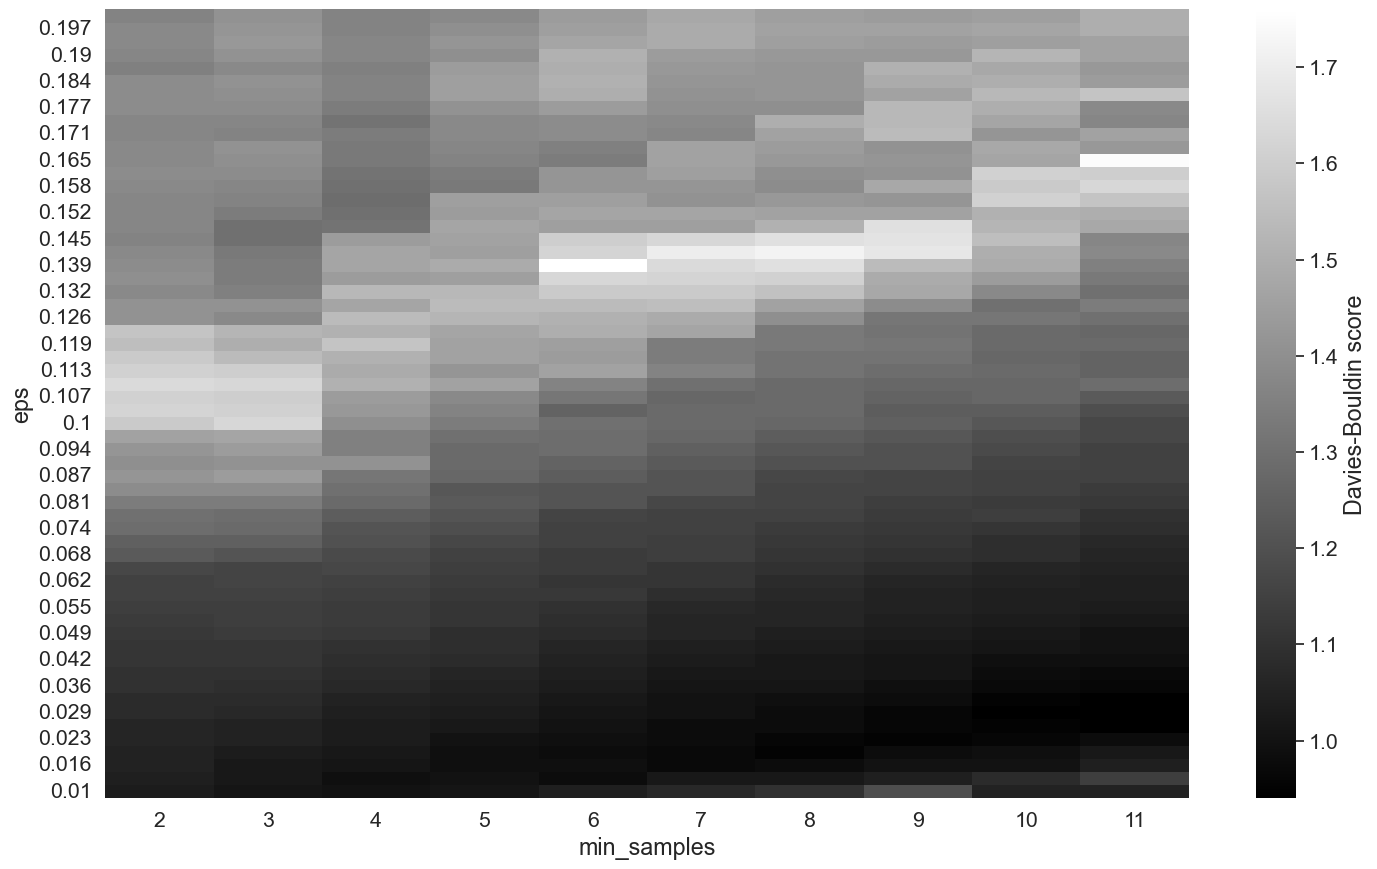

Minimum Davies-Bouldin score here:        eps  min_samples clustering_on  scores_on  nclusters  silhouette  \
236  0.026           11     embedding  embedding      139.0      -0.785   
272  0.029           10     embedding  embedding      240.0      -0.767   
276  0.029           11     embedding  embedding      184.0      -0.772   
316  0.033           11     embedding  embedding      242.0      -0.749   

     davies_bouldin  calinski  nnoise  
236            0.94      27.0    95.0  
272            0.94      28.0    91.0  
276            0.94      29.0    92.0  
316            0.94      32.0    90.0  
Minimum Davies-Bouldin score (where nnoise<=5) here:         eps  min_samples clustering_on  scores_on  nclusters  silhouette  \
1808  0.155            4     embedding  embedding       97.0      -0.568   

      davies_bouldin  calinski  nnoise  
1808            1.29     302.0     1.0  


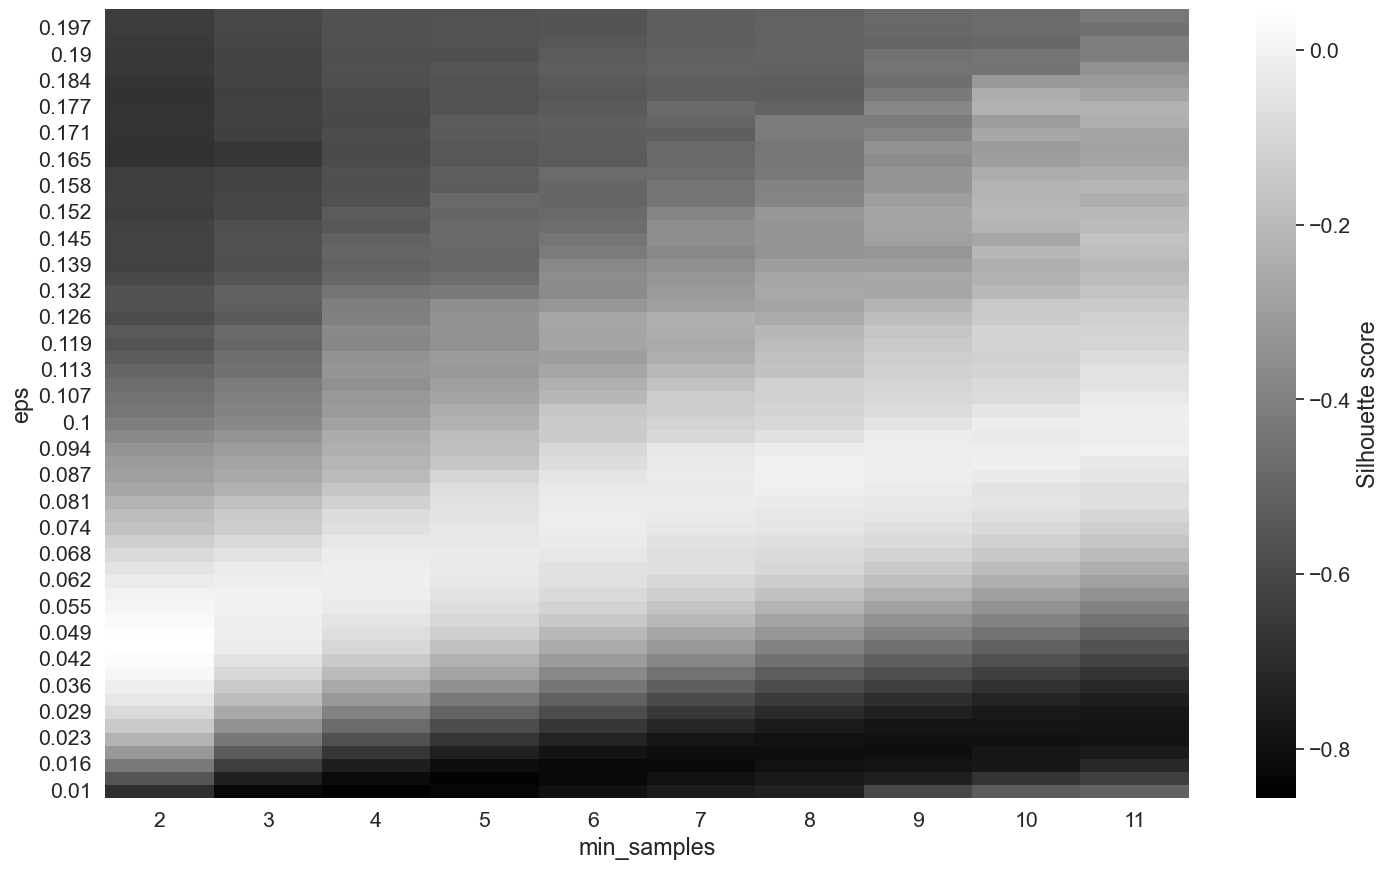

Maximum Silhouette score here:        eps  min_samples clustering_on  scores_on  nclusters  silhouette  \
440  0.045            2     embedding  embedding     5041.0       0.046   

     davies_bouldin  calinski  nnoise  
440            1.11      44.0    19.0  
Maximum Silhouette score (where nnoise<=5) here:        eps  min_samples clustering_on  scores_on  nclusters  silhouette  \
840  0.078            2     embedding  embedding     1920.0      -0.187   

     davies_bouldin  calinski  nnoise  
840             1.3     431.0     5.0  


In [42]:
# plot score heatmap for clustering on embedding and scores on embedding
clustering_on = "embedding"
scores_on = "embedding"

plt.rcParams["figure.figsize"] = (15, 9)
sns.set(font_scale=1.4)

# prepare and filter data
temp = df_dbscan_i[(df_dbscan_i["clustering_on"] == clustering_on) & (df_dbscan_i["scores_on"] == scores_on)].copy()
temp.eps = temp.eps.round(3)
temp.min_samples = temp.min_samples.astype(int)
temp.silhouette = temp.silhouette.round(3)
temp.calinski = temp.calinski.round()
temp.davies_bouldin = temp.davies_bouldin.round(2)
temp.nclusters = np.round(temp.nclusters)
temp["nnoise"] = round(temp["nnoise"]*100/49131)
t = temp[temp.nnoise <= 5]

# noise fraction
# field_n, [diff_max_n, col_max0_n, row_max0_n, col_max1_n, row_max1_n] = plot_heatmap(temp, x="min_samples", y="eps", color="nnoise", title=f"Sweep of DBSCAN (clustering on {clustering_on}, scores on {scores_on})")  # , vmax=5)
field_n, [diff_max_n, col_max0_n, row_max0_n, col_max1_n, row_max1_n] = plot_heatmap(temp, x="min_samples", y="eps", color="nnoise", title="", annot=False)  # , vmax=5)
plt.show()
print(f"Maximum gradient: {diff_max_n}, between entry(col, row) {col_max0_n, row_max0_n} and entry(col, row) {col_max1_n, row_max1_n}")

# noise fraction (with mask for 5%)
# field_5, [diff_max_5, col_max0_5, row_max0_5, col_max1_5, row_max1_5] = plot_heatmap(temp, x="min_samples", y="eps", color="nnoise", title=f"Sweep of DBSCAN (clustering on {clustering_on}, scores on {scores_on})", mask=field_n <= 5)
field_5, [diff_max_5, col_max0_5, row_max0_5, col_max1_5, row_max1_5] = plot_heatmap(temp, x="min_samples", y="eps", color="nnoise", title="", mask=field_n <= 5, annot=False)
plt.show()
print(f"Maximum gradient (nnoise <=5): {diff_max_5}, between entry(col, row) {col_max0_5, row_max0_5} and entry(col, row) {col_max1_5, row_max1_5}")

# number of clusters
# field, [diff_max, col_max0, row_max0, col_max1, row_max1] = plot_heatmap(temp, x="min_samples", y="eps", color="nclusters", title=f"Sweep of DBSCAN (clustering on {clustering_on}, scores on {scores_on})")
field, [diff_max, col_max0, row_max0, col_max1, row_max1] = plot_heatmap(temp, x="min_samples", y="eps", color="nclusters", title="", annot=False)
plt.savefig(f"{config.output_dir_plots}dbscan/sweep_clustering_on_{clustering_on}_scores_on{scores_on}.png")
plt.show()
print(f"Maximum gradient: {diff_max}, between entry(col, row) {col_max0, row_max0} and entry(col, row) {col_max1, row_max1}")

# Calinski-Harabasz
# field_ch, vs_ch = plot_heatmap(temp, x="min_samples", y="eps", color="calinski", title=f"Sweep of DBSCAN (clustering on {clustering_on}, scores on {scores_on})")
field_ch, vs_ch = plot_heatmap(temp, x="min_samples", y="eps", color="calinski", title="", annot=False, patch=(np.round(0.10983051, 3), 4))
plt.savefig(f"{config.output_dir_plots}dbscan/sweep_clustering_on_{clustering_on}_scores_on{scores_on}_calinski.png")
plt.show()
print(f"Maximum Calinski-Harabasz score here: {temp[temp.calinski == temp.calinski.max()]}")
print(f"Maximum Calinski-Harabasz score (where nnoise<=5) here: {t[t.calinski == t.calinski.max()]}")

# Davies-Bouldin
# field_db, vs_db = plot_heatmap(temp, x="min_samples", y="eps", color="davies_bouldin", title=f"Sweep of DBSCAN (clustering on {clustering_on}, scores on {scores_on})")
field_db, vs_db = plot_heatmap(temp, x="min_samples", y="eps", color="davies_bouldin", title="", annot=False)
plt.savefig(f"{config.output_dir_plots}dbscan/sweep_clustering_on_{clustering_on}_scores_on{scores_on}_davies_bouldin.png")
plt.show()
print(f"Minimum Davies-Bouldin score here: {temp[temp.davies_bouldin == temp.davies_bouldin.min()]}")
print(f"Minimum Davies-Bouldin score (where nnoise<=5) here: {t[t.davies_bouldin == t.davies_bouldin.min()]}")

# Silhouette
# field_s, vs_s = plot_heatmap(temp, x="min_samples", y="eps", color="silhouette", title=f"Sweep of DBSCAN (clustering on {clustering_on}, scores on {scores_on})")
field_s, vs_s = plot_heatmap(temp, x="min_samples", y="eps", color="silhouette", title="", annot=False)
plt.savefig(f"{config.output_dir_plots}dbscan/sweep_clustering_on_{clustering_on}_scores_on{scores_on}_silhouette.png")
plt.show()
print(f"Maximum Silhouette score here: {temp[temp.silhouette == temp.silhouette.max()]}")
print(f"Maximum Silhouette score (where nnoise<=5) here: {t[t.silhouette == t.silhouette.max()]}")
